# 01 · The travelling wave, interactively

$E(z,t) = E_0 \cos(\omega t - \beta z)$ (NOTES §2) and its phasor $\tilde E(z) e^{j\omega t}$ with $\tilde E(z) = E_0 e^{-j\beta z}$ (NOTES §3).

Move the sliders: **n** changes the index the wave sees (1 = vacuum, 2.5 = the textbook mode index, 3.5 = bulk silicon), **sign** flips the direction, **t** advances time. Watch three things at once: the snapshot in $z$, the phasor at the probe point $z_0$, and the time trace at $z_0$.

In [1]:
%matplotlib inline
import sys, pathlib
HERE = pathlib.Path.cwd()
ROOT = HERE.parents[1]
sys.path.insert(0, str(ROOT)); sys.path.insert(0, str(HERE))
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
from common import REF, use_style, SERIES, PALETTE, C0
from twave import wave_numbers, E_real, E_phasor, E_from_phasor, track_crest, fit_velocity, round_trip_phase
use_style(dpi=100)

W = wave_numbers(REF.lambda_nm, n=REF.neff)
T_FS = W["T_s"] * 1e15
print(f"lambda0 = {REF.lambda_nm:.0f} nm, T = {T_FS:.3f} fs, n_eff = {REF.neff}: lambda_g = {W['lambda_med_m']*1e9:.1f} nm, v_p = {W['v_p_m_s']:.4e} m/s")

lambda0 = 1310 nm, T = 4.370 fs, n_eff = 2.5: lambda_g = 524.0 nm, v_p = 1.1992e+08 m/s


In [2]:
def show_wave(n=2.5, sign="+z (e^{-jβz})", t_fs=0.0, z0_nm=250.0):
    sgn = -1 if sign.startswith("+z") else +1
    Wn = wave_numbers(REF.lambda_nm, n=n)
    om, be = Wn["omega_rad_s"], Wn["beta_rad_m"]
    lam_g = Wn["lambda_med_m"] * 1e9
    z = np.linspace(0, 1600, 1601)
    t = t_fs * 1e-15
    fig, axs = plt.subplots(1, 3, figsize=(14, 3.8), gridspec_kw={"width_ratios": [1.5, 0.9, 1.2]})
    # snapshot
    ax = axs[0]
    ax.plot(z, E_real(z * 1e-9, t, om, be, sgn), color=SERIES[0])
    zc = (sgn * -1) * Wn["v_p_m_s"] * t * 1e9          # crest that sat at z = 0 at t = 0
    zc = zc % lam_g
    for k in range(int(1600 / lam_g) + 1):
        ax.plot(zc + k * lam_g, 1.0, "o", color=SERIES[1], ms=7)
    ax.axvline(z0_nm, color=SERIES[3], ls="--", lw=1)
    ax.plot(z0_nm, E_real(z0_nm * 1e-9, t, om, be, sgn), "o", color=SERIES[3], ms=8)
    ax.set_ylim(-1.3, 1.3); ax.set_xlabel("z (nm)"); ax.set_ylabel("E / E₀")
    ax.set_title(f"n = {n:.2f}: λ = {lam_g:.0f} nm, v_p = {Wn['v_p_m_s']:.3e} m/s, t = {t_fs:.2f} fs", fontsize=10)
    # phasor at z0
    ax = axs[1]
    th = np.linspace(0, 2 * np.pi, 200)
    ax.plot(np.cos(th), np.sin(th), color=PALETTE["line"]); ax.axhline(0, color=PALETTE["muted"], lw=0.8); ax.axvline(0, color=PALETTE["muted"], lw=0.8)
    p = E_phasor(z0_nm * 1e-9, be, sgn) * np.exp(1j * om * t)
    ax.add_patch(FancyArrowPatch((0, 0), (p.real, p.imag), arrowstyle="-|>", mutation_scale=16, color=SERIES[3], lw=2))
    ax.plot([p.real, p.real], [p.imag, 0], color=SERIES[3], ls=":"); ax.plot(p.real, 0, "o", color=SERIES[3])
    ax.set_xlim(-1.3, 1.3); ax.set_ylim(-1.3, 1.3); ax.set_aspect("equal"); ax.set_xlabel("Re Ẽ / E₀"); ax.set_ylabel("Im Ẽ / E₀")
    ax.set_title(f"phasor at z₀ = {z0_nm:.0f} nm: phase {np.degrees(np.angle(p)):+.0f}°", fontsize=10)
    # time trace
    ax = axs[2]
    tt = np.linspace(0, 3 * T_FS, 500)
    ax.plot(tt, E_real(z0_nm * 1e-9, tt * 1e-15, om, be, sgn), color=SERIES[3], alpha=0.35)
    keep = tt <= t_fs
    ax.plot(tt[keep], E_real(z0_nm * 1e-9, tt[keep] * 1e-15, om, be, sgn), color=SERIES[3])
    ax.plot(t_fs, p.real, "o", color=SERIES[3], ms=8)
    ax.set_ylim(-1.3, 1.3); ax.set_xlabel("t (fs)"); ax.set_ylabel("E(z₀, t) / E₀")
    ax.set_title(f"time trace at z₀; period T = {T_FS:.2f} fs for every n", fontsize=10)
    plt.tight_layout(); plt.show()

### Live sliders

In [3]:
import ipywidgets as w
w.interact(show_wave,
           n=w.FloatSlider(value=2.5, min=1.0, max=3.5, step=0.05, description="n"),
           sign=w.Dropdown(options=["+z (e^{-jβz})", "−z (e^{+jβz})"], value="+z (e^{-jβz})", description="sign"),
           t_fs=w.FloatSlider(value=0.0, min=0.0, max=3 * T_FS, step=0.05, description="t (fs)"),
           z0_nm=w.FloatSlider(value=250.0, min=0.0, max=1500.0, step=10.0, description="z₀ (nm)"));

interactive(children=(FloatSlider(value=2.5, description='n', max=3.5, min=1.0, step=0.05), Dropdown(descripti…

## Static gallery (so the executed notebook shows figures without a live kernel)

Three settings: vacuum, the textbook mode index, and bulk silicon, all at the same $t$. The period is identical; only the wavelength along $z$ (and therefore $v_p = \omega/\beta$) changes.

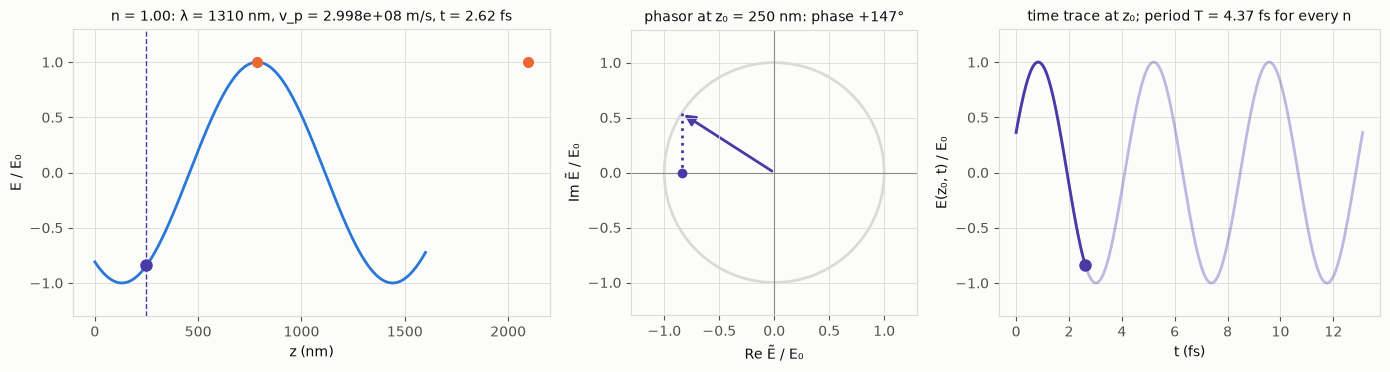

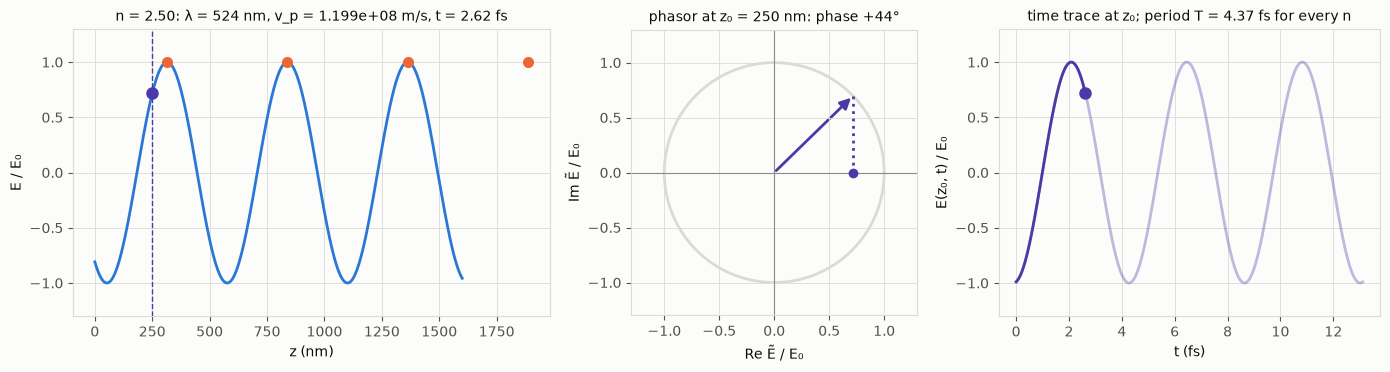

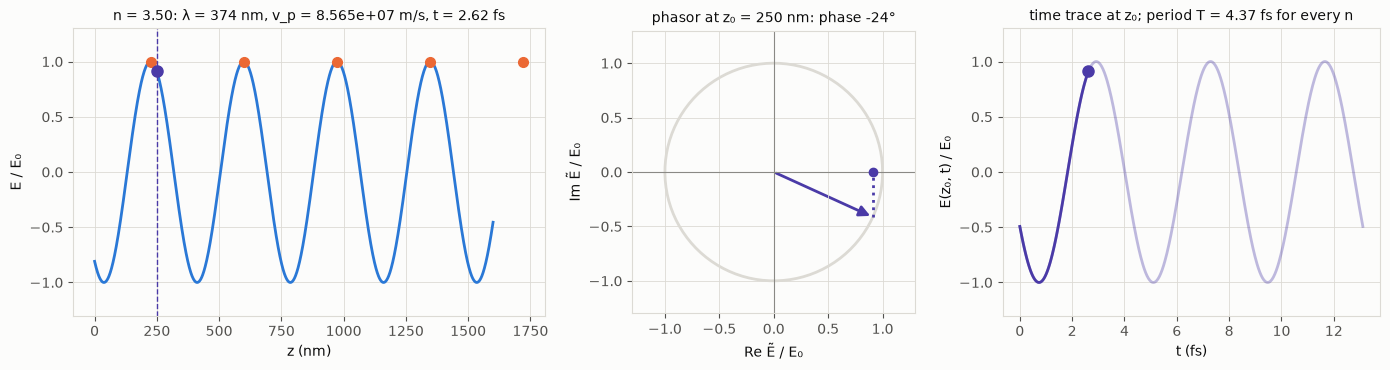

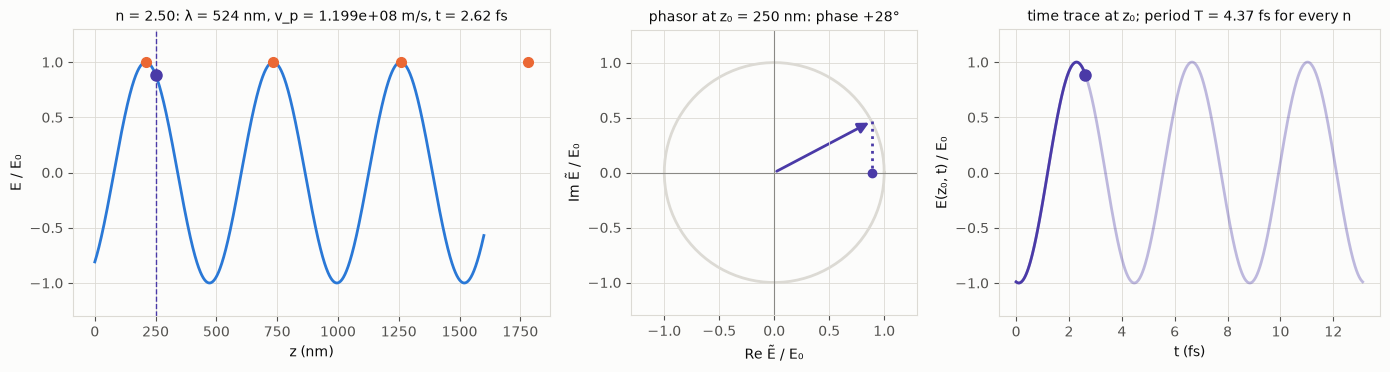

In [4]:
for n in (1.0, 2.5, 3.5):
    show_wave(n=n, t_fs=0.6 * T_FS)
show_wave(n=2.5, sign="−z (e^{+jβz})", t_fs=0.6 * T_FS)

## Crest tracking gives $v_p = \omega/\beta$ (NOTES §2)

Follow one crest numerically through time; its position is a straight line with slope $\omega/\beta$. Change `n` and `sign` here as well.

findfont: Failed to find font weight medium for DejaVu Sans, now using 400.


tracked crest velocity = 1.19917e+08 m/s; omega/beta = 1.19917e+08 m/s; c/n = 1.19917e+08 m/s


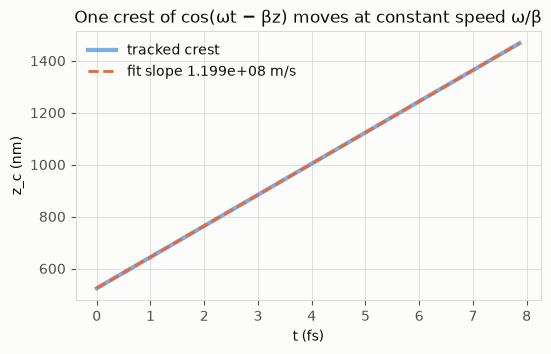

In [5]:
n, sign = 2.5, -1
Wn = wave_numbers(REF.lambda_nm, n=n); om, be = Wn["omega_rad_s"], Wn["beta_rad_m"]
lam_g = Wn["lambda_med_m"]
z = np.linspace(0, 3 * lam_g, 4000); t = np.linspace(0, 1.8 * T_FS, 400) * 1e-15
zc = track_crest(z, t, om, be, sign=sign, z_start=(lam_g if sign == -1 else 2 * lam_g))
v, b = fit_velocity(t, zc)
print(f"tracked crest velocity = {v:.5e} m/s; omega/beta = {sign * -1 * om / be:.5e} m/s; c/n = {C0 / n:.5e} m/s")
plt.figure(figsize=(6, 3.5)); plt.plot(t * 1e15, zc * 1e9, lw=3, alpha=0.6, label="tracked crest")
plt.plot(t * 1e15, (v * t + b) * 1e9, "--", label=f"fit slope {v:.3e} m/s"); plt.xlabel("t (fs)"); plt.ylabel("z_c (nm)")
plt.title("One crest of cos(ωt − βz) moves at constant speed ω/β"); plt.legend(); plt.show()

## Phasor identity check (NOTES §3)

$\operatorname{Re}\{E_0 e^{-j\beta z} e^{j\omega t}\}$ must equal $E_0\cos(\omega t - \beta z)$ at every $(z,t)$. With $e^{+j\beta z}$ instead, the same identity gives the backward wave: the consistent pairs are $e^{j\omega t}e^{-j\beta z}$ or $e^{-j\omega t}e^{+j\beta z}$.

In [6]:
Z, T = np.meshgrid(np.linspace(0, 3e-6, 601), np.linspace(0, 3 * T_FS, 301) * 1e-15)
for sgn, name in ((-1, "e^{-jβz}"), (+1, "e^{+jβz}")):
    d = np.max(np.abs(E_from_phasor(Z, T, om, be, sgn) - E_real(Z, T, om, be, sgn)))
    print(f"{name}: max |Re{{phasor}} - cos| = {d:.2e}")

e^{-jβz}: max |Re{phasor} - cos| = 3.62e-15
e^{+jβz}: max |Re{phasor} - cos| = 3.71e-15


## Capstone: one lap of the ring is $e^{-j\beta L}$

The ring transfer function is written in exactly this phasor convention: the field after a lap is $a\,e^{-j\beta L}$ times the field before (NOTES §28). Resonance is $\beta L = 2\pi m$. Heating the ring raises $n_{\rm eff}$ ($\Gamma\,dn_{\rm Si}/dT$), which rotates the round-trip phasor clockwise by $k_0 L\, dn_{\rm eff}/dT$ per kelvin, and moves the resonance by $(\lambda/n_g)\,dn_{\rm eff}/dT \approx 50$ pm/K. Change `dT_K` below.

beta L at 1310 nm = 474.84 rad = 75.573 x 2pi
round-trip phase drift = 0.0303 rad/K = 1.74 deg/K -> 17.4 deg for 10 K
resonance shift = 49.8 pm/K -> 0.50 nm for 10 K (REF: 50.0 pm/K; FWHM 374 pm)


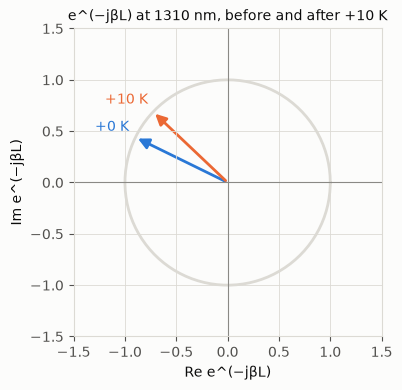

In [7]:
dT_K = 10.0
L_um = REF.round_trip_um
dneff_dT = REF.confinement * REF.dn_si_dT + (1 - REF.confinement) * REF.dn_sio2_dT
phi0 = round_trip_phase(REF.lambda_nm, L_um)
dphi = 2 * np.pi / (REF.lambda_nm * 1e-3) * L_um * dneff_dT       # rad per K
dlam_pm = REF.lambda_nm * 1e3 * dneff_dT / REF.ng
print(f"beta L at 1310 nm = {phi0:.2f} rad = {phi0/2/np.pi:.3f} x 2pi")
print(f"round-trip phase drift = {dphi:.4f} rad/K = {np.degrees(dphi):.2f} deg/K -> {np.degrees(dphi*dT_K):.1f} deg for {dT_K:.0f} K")
print(f"resonance shift = {dlam_pm:.1f} pm/K -> {dlam_pm*dT_K/1e3:.2f} nm for {dT_K:.0f} K (REF: {REF.dlambda_dT_pm_per_K} pm/K; FWHM {REF.fwhm_pm:.0f} pm)")
fig, ax = plt.subplots(figsize=(4, 4)); th = np.linspace(0, 2*np.pi, 200)
ax.plot(np.cos(th), np.sin(th), color=PALETTE["line"]); ax.axhline(0, color=PALETTE["muted"], lw=0.8); ax.axvline(0, color=PALETTE["muted"], lw=0.8)
for k, (dT, col) in enumerate(((0, SERIES[0]), (dT_K, SERIES[1]))):
    p = np.exp(-1j * (phi0 + dphi * dT))
    ax.add_patch(FancyArrowPatch((0, 0), (p.real, p.imag), arrowstyle="-|>", mutation_scale=16, color=col, lw=2))
    ha = "right" if p.real < -0.05 else ("left" if p.real > 0.05 else "center")   # text extends outward, off the arrows
    ax.text(1.07 * p.real, 1.07 * p.imag, f"+{dT:.0f} K", color=col, ha=ha, va="bottom" if p.imag > 0 else "top")
ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5); ax.set_aspect("equal"); ax.set_xlabel("Re e^(−jβL)"); ax.set_ylabel("Im e^(−jβL)")
ax.set_title(f"e^(−jβL) at 1310 nm, before and after +{dT_K:.0f} K", fontsize=10); plt.show()